<a href="https://colab.research.google.com/github/farukkilinc1903/group6-innovation-campus-samsung/blob/main/3Model.and.Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Xgboost-Random Forest-Gradient Boosting Comparison**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

###Load Datasets

In [ ]:
school_df = pd.read_csv("d0.school_electricity_access.csv")

national_electricity_df = pd.read_csv("d1.TOT.ELCT.ACCS.csv", skiprows=4)
gdp_df = pd.read_csv("d2.GDP.DATA.csv", skiprows=4)
education_df = pd.read_csv("d3.EDU.EXP.csv", skiprows=4)
urban_df = pd.read_csv("d4.URBAN.POP.csv", skiprows=4)

nasa_df = pd.read_excel("d5.NASA.UYDU.xlsx", sheet_name="Data")

print("Datasets loaded successfully.")

Datasets loaded successfully.


###World Bank Data Preparation

In [ ]:
def format_world_bank_data(df, value_name):
    years = [str(year) for year in range(1992, 2014)]

    df_long = df.melt(
        id_vars=["Country Code"],
        value_vars=years,
        var_name="Year",
        value_name=value_name
    )

    df_long["Year"] = df_long["Year"].astype(int)
    df_long = df_long.rename(columns={"Country Code": "ISO"})

    return df_long

In [ ]:
national_electricity_long = format_world_bank_data(
    national_electricity_df,
    "National_Electricity_Access"
)

gdp_long = format_world_bank_data(
    gdp_df,
    "GDP_per_Capita"
)

education_long = format_world_bank_data(
    education_df,
    "Education_Expenditure"
)

urban_long = format_world_bank_data(
    urban_df,
    "Urban_Population"
)

print("World Bank datasets converted successfully.")

World Bank datasets converted successfully.


###NASA and School Data Preparation

In [ ]:
school_df = school_df.rename(columns={"ISO_Code": "ISO"})

nasa_selected = nasa_df[
    ["ISO", "Year", "stbSoL", "Lpc", "Pdens", "wGini_L050"]
]

school_selected = school_df[
    ["ISO", "Year", "Electricity_Access_Percent"]
]

###Merge Datasets

In [ ]:
merged_df = pd.merge(
    school_selected,
    nasa_selected,
    on=["ISO", "Year"],
    how="inner"
)

merged_df = pd.merge(
    merged_df,
    national_electricity_long,
    on=["ISO", "Year"],
    how="inner"
)

merged_df = pd.merge(
    merged_df,
    gdp_long,
    on=["ISO", "Year"],
    how="inner"
)

merged_df = pd.merge(
    merged_df,
    education_long,
    on=["ISO", "Year"],
    how="inner"
)

merged_df = pd.merge(
    merged_df,
    urban_long,
    on=["ISO", "Year"],
    how="inner"
)

merged_df = merged_df.dropna()

print("Final dataset shape:", merged_df.shape)
merged_df.head()

Final dataset shape: (223, 11)


,ISO,Year,Electricity_Access_Percent,stbSoL,Lpc,Pdens,wGini_L050,National_Electricity_Access,GDP_per_Capita,Education_Expenditure,Urban_Population
1,ARG,2009,92.342361,2.854422e+06,0.071943,14.251959,0.629623,97.8,8150.235270,16.020670,90.820902
2,ABW,2010,100.000000,7.212818e+03,0.071073,448.464824,0.551859,93.4,24093.140151,22.176781,64.161297
18,BGD,2012,55.384041,4.007569e+05,0.002742,1024.967497,0.736576,65.5,859.680536,15.745120,28.478797
19,BRB,2009,100.000000,1.599105e+04,0.057769,564.269337,0.478147,100.0,16294.909949,16.100580,59.294492
22,BEL,2005,100.000000,1.401670e+06,0.133186,342.414704,0.525086,100.0,36809.701340,11.175520,83.564545


###Define Features and Target

In [ ]:
X = merged_df.drop(columns=["ISO", "Year", "Electricity_Access_Percent"])
y = merged_df["Electricity_Access_Percent"]

print("Features:")
print(X.columns)

print("Target:")
print(y.name)

Features:
Index(['stbSoL', 'Lpc', 'Pdens', 'wGini_L050', 'National_Electricity_Access',
       'GDP_per_Capita', 'Education_Expenditure', 'Urban_Population'],
      dtype='object')
Target:
Electricity_Access_Percent


###Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

###Random Forest Model

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest Results")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Results
R2 Score: 0.8475589514381239
MAE: 3.4018542001512304
RMSE: 9.262789719619562


###XGBoost Model

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_predictions)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost Results")
print("R2 Score:", xgb_r2)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

XGBoost Results
R2 Score: 0.8982137850839369
MAE: 2.5464286380343966
RMSE: 7.568944550465274


###Gradient Boosting Model

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, gb_predictions)
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

print("Gradient Boosting Results")
print("R2 Score:", gb_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)

Gradient Boosting Results
R2 Score: 0.7102633183160147
MAE: 3.6595769315675537
RMSE: 12.770049544675407


###Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Gradient Boosting"
    ],
    "R2 Score": [
        rf_r2,
        xgb_r2,
        gb_r2
    ],
    "MAE": [
        rf_mae,
        xgb_mae,
        gb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse,
        gb_rmse
    ]
})

model_comparison

,Model,R2 Score,MAE,RMSE
0,Random Forest,0.847559,3.401854,9.262790
1,XGBoost,0.898214,2.546429,7.568945
2,Gradient Boosting,0.710263,3.659577,12.770050


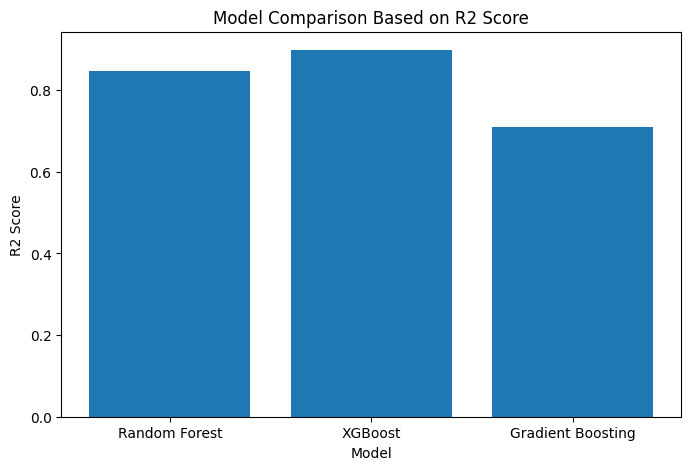

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["R2 Score"])
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()

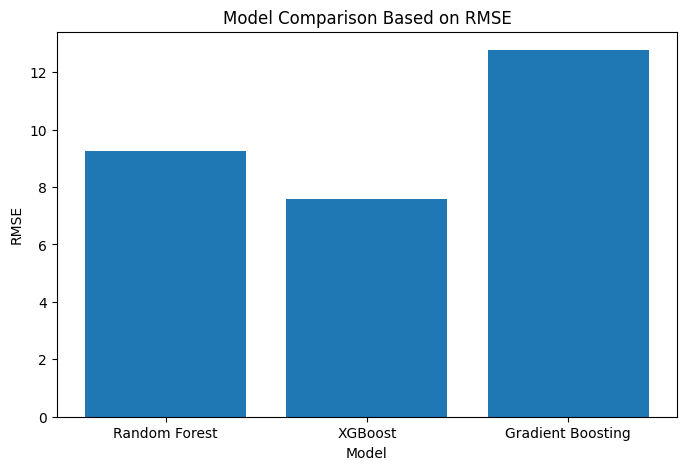

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

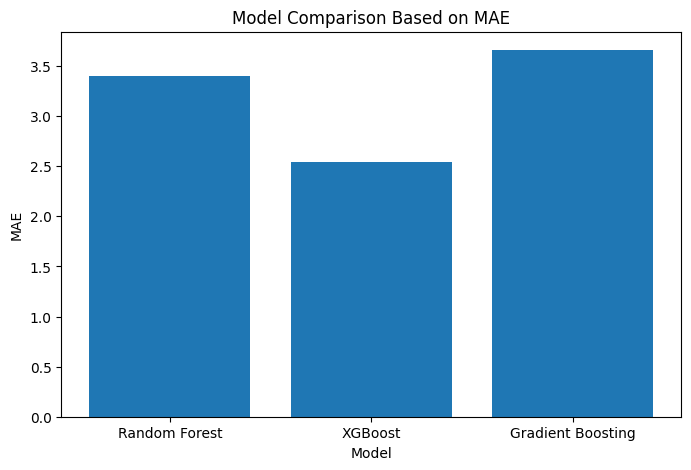

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

In [ ]:
best_model = model_comparison.sort_values(by="R2 Score", ascending=False).iloc[0]

print("Best Model Result")
print("Model:", best_model["Model"])
print("R2 Score:", best_model["R2 Score"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])

Best Model Result
Model: XGBoost
R2 Score: 0.8982137850839369
MAE: 2.5464286380343966
RMSE: 7.568944550465274


###Feature Importance Analysis of the Best Model

In [ ]:
best_model_row = model_comparison.sort_values(by="R2 Score", ascending=False).iloc[0]
best_model_name = best_model_row["Model"]

if best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "XGBoost":
    best_model = xgb_model

elif best_model_name == "Gradient Boosting":
    best_model = gb_model


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,GDP_per_Capita,0.866308
3,wGini_L050,0.056315
4,National_Electricity_Access,0.036290
0,stbSoL,0.025337
2,Pdens,0.014214
6,Education_Expenditure,0.000620
7,Urban_Population,0.000494
1,Lpc,0.000423


In [ ]:
# Select the best model based on the highest R2 Score

model_comparison = model_comparison.sort_values(by="R2 Score", ascending=False)

best_model_name = model_comparison.iloc[0]["Model"]

if best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "XGBoost":
    best_model = xgb_model

else:
    best_model = gb_model

print("Best model:", best_model_name)

Best model: XGBoost


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,GDP_per_Capita,0.866308
3,wGini_L050,0.056315
4,National_Electricity_Access,0.036290
0,stbSoL,0.025337
2,Pdens,0.014214
6,Education_Expenditure,0.000620
7,Urban_Population,0.000494
1,Lpc,0.000423


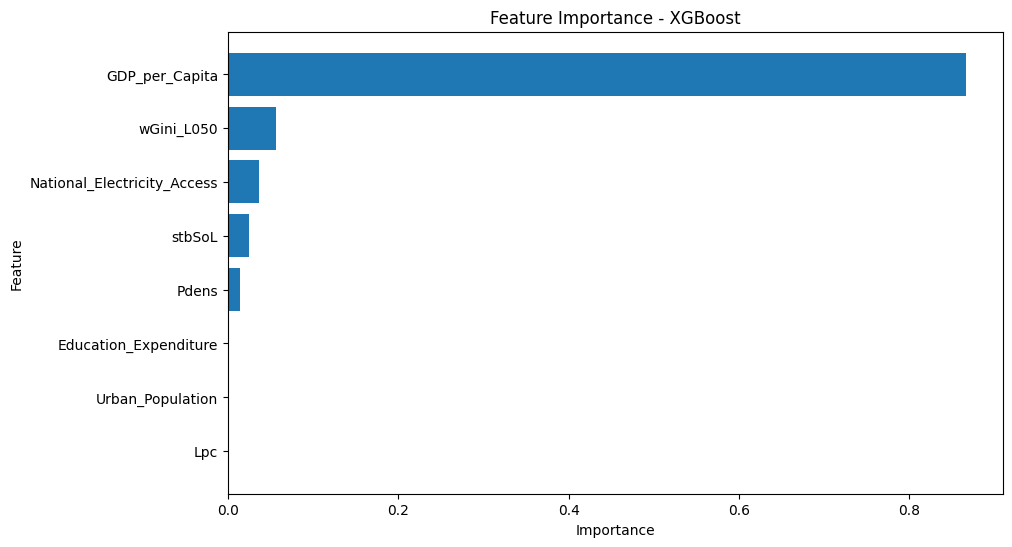

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - " + best_model_name)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

####XGBoost achieved the best overall performance with the highest R2 score and the lowest MAE and RMSE values. Therefore, it was selected as the best-performing model. Feature importance analysis was applied to XGBoost to identify the most influential predictors of school electricity access. This helps explain whether infrastructure, economic, educational, or satellite-based indicators had the strongest effect on the prediction.